In [4]:
# Importing libraries

import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset
import ast

# Loading data

dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data clean up

df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
# cuz this date column was type str, now changed to type datetime
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)
# converting string formatted list to actual list

d:\Program Files\Anaconda\envs\python_course\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [6]:
df_da = df[df['job_title_short'] == 'Data Analyst'].copy()

df_da['job_month'] = df_da['job_posted_date'].dt.month

df_da_exploded = df_da.explode('job_skills')

df_da_pivot = df_da_exploded.pivot_table(index = 'job_month', columns='job_skills',  aggfunc = 'size', fill_value = 0)

df_da_pivot

job_skills,airflow,airtable,alteryx,angular,angular.js,ansible,apl,arch,asana,asp.net,...,webex,windows,wire,word,workfront,wrike,wsl,xamarin,yarn,zoom
job_month,,,,,,,,,,,,,,,,,,,,,
1,197,17,551,63,2,20,2,1,29,34,...,17,228,6,1778,0,11,6,0,9,95
2,169,2,448,49,0,14,1,4,27,13,...,9,202,6,1235,4,2,5,0,4,41
3,181,4,442,34,0,23,6,1,17,13,...,8,194,8,1203,1,1,3,1,5,45
4,155,4,413,22,0,11,8,9,9,15,...,9,185,14,1177,8,2,1,0,6,26
5,128,8,310,30,0,19,9,2,8,21,...,11,122,3,957,3,4,0,0,7,18
6,164,14,393,29,0,14,9,4,16,16,...,8,157,14,1237,6,6,0,0,11,34
7,207,4,366,15,0,8,5,8,19,12,...,5,161,11,1069,0,3,0,0,6,38
8,197,3,413,21,0,12,10,3,13,12,...,9,184,11,1298,0,1,0,0,11,41
9,118,4,317,21,0,14,3,10,12,10,...,4,150,8,945,0,1,0,0,5,25


In [7]:
# Create a total row
df_da_pivot.loc['Total'] = df_da_pivot.sum()

# Order columns by total count
df_da_pivot = df_da_pivot[df_da_pivot.loc['Total'].sort_values(ascending =  False).index]

# Drop total row
df_da_pivot = df_da_pivot.drop('Total')

df_da_pivot

job_skills,sql,excel,python,tableau,power bi,r,sas,powerpoint,word,sap,...,xamarin,mattermost,gtx,esquisse,chainer,capacitor,nuxt.js,msaccess,ovh,suse
job_month,,,,,,,,,,,,,,,,,,,,,
1,11336,8170,6606,5596,4285,3607,3830,1880,1778,1251,...,0,0,0,0,0,1,1,0,0,0
2,7947,5772,4751,3936,3307,2576,2634,1291,1235,954,...,0,0,0,0,0,0,0,0,0,0
3,7868,5675,4741,4051,3176,2650,2554,1266,1203,892,...,1,0,0,0,0,0,0,0,0,1
4,7553,5496,4557,3776,3106,2399,2598,1190,1177,947,...,0,0,0,0,0,0,0,0,1,0
5,6617,4773,4070,3245,2695,2093,1940,979,957,851,...,0,0,0,0,0,0,0,1,0,0
6,7584,5724,4707,3812,3275,2442,2174,1173,1237,987,...,0,0,0,0,0,0,0,0,0,0
7,7687,5513,4831,3928,3350,2444,2118,1096,1069,996,...,0,0,1,0,0,0,0,0,0,0
8,8823,6482,5576,4533,3859,2975,2560,1332,1298,1117,...,0,0,0,0,0,0,0,0,0,0
9,6829,4886,4229,3446,3118,2146,1880,944,945,852,...,0,1,0,0,0,0,0,0,0,0


In [8]:
df_da_pivot = df_da_pivot.reset_index()

df_da_pivot['job_posted_month'] = df_da_pivot['job_month'].apply(lambda x: pd.to_datetime(x, format='%m').strftime('%b'))
# new column job_posted_month where Jan Feb Mar ...

df_da_pivot = df_da_pivot.set_index('job_posted_month')
df_da_pivot = df_da_pivot.drop(columns = 'job_month')

df_da_pivot

job_skills,sql,excel,python,tableau,power bi,r,sas,powerpoint,word,sap,...,xamarin,mattermost,gtx,esquisse,chainer,capacitor,nuxt.js,msaccess,ovh,suse
job_posted_month,,,,,,,,,,,,,,,,,,,,,
Jan,11336,8170,6606,5596,4285,3607,3830,1880,1778,1251,...,0,0,0,0,0,1,1,0,0,0
Feb,7947,5772,4751,3936,3307,2576,2634,1291,1235,954,...,0,0,0,0,0,0,0,0,0,0
Mar,7868,5675,4741,4051,3176,2650,2554,1266,1203,892,...,1,0,0,0,0,0,0,0,0,1
Apr,7553,5496,4557,3776,3106,2399,2598,1190,1177,947,...,0,0,0,0,0,0,0,0,1,0
May,6617,4773,4070,3245,2695,2093,1940,979,957,851,...,0,0,0,0,0,0,0,1,0,0
Jun,7584,5724,4707,3812,3275,2442,2174,1173,1237,987,...,0,0,0,0,0,0,0,0,0,0
Jul,7687,5513,4831,3928,3350,2444,2118,1096,1069,996,...,0,0,1,0,0,0,0,0,0,0
Aug,8823,6482,5576,4533,3859,2975,2560,1332,1298,1117,...,0,0,0,0,0,0,0,0,0,0
Sep,6829,4886,4229,3446,3118,2146,1880,944,945,852,...,0,1,0,0,0,0,0,0,0,0


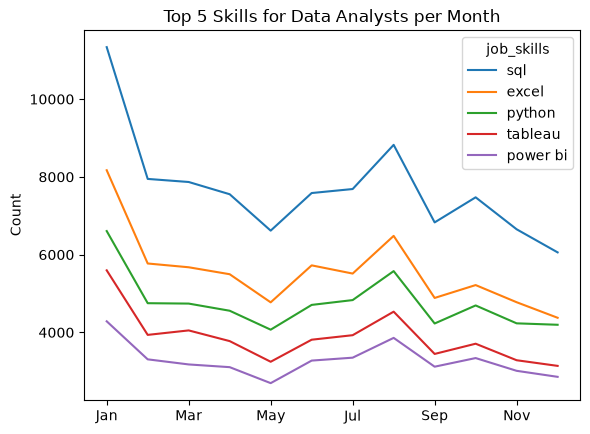

In [9]:
df_da_pivot.iloc[:, :5].plot(kind='line')

plt.title('Top 5 Skills for Data Analysts per Month')
plt.ylabel('Count')
plt.xlabel('')
plt.show()

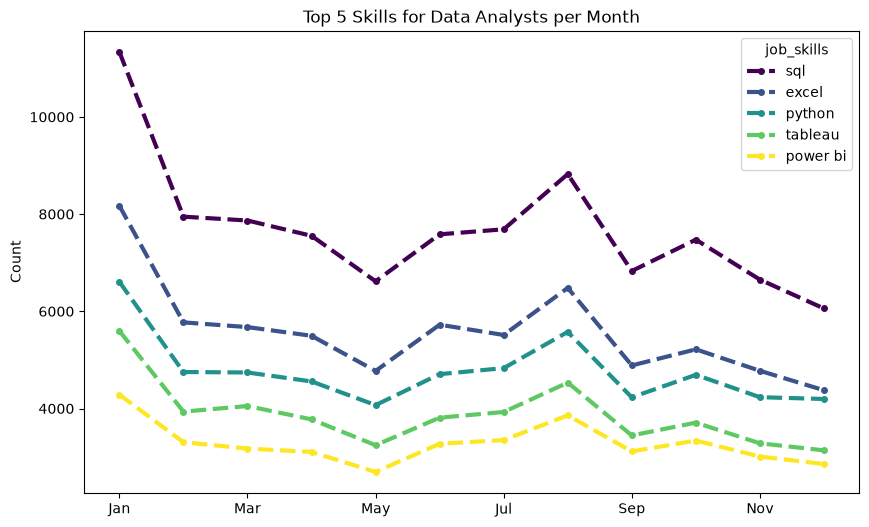

In [10]:
df_da_pivot.iloc[:, :5].plot(kind='line',
                             linewidth = 3, 
                             linestyle = '--',  #options: "-" ; "--" ; "-."
                             colormap = 'viridis',  #options: "plasma" ; "inferno" ; "cividis" ; "magma"
                             marker = 'o',  #options: "x" ; "+" ; "*" ; "s" ; "," ; "." ; "1" ....
                             markersize = 4,
                             figsize = (10,6))



plt.title('Top 5 Skills for Data Analysts per Month')
plt.ylabel('Count')
plt.xlabel('')
plt.show()

In [11]:
####################################################################

In [12]:
df = df[df['job_title_short'] == 'Data Analyst']

df_exploded = df.explode('job_skills')

df_exploded.groupby('job_skills').size()

skill_stats = df_exploded.groupby('job_skills').agg(
    skill_count = ('job_skills', 'count'),
    median_salary = ('salary_year_avg', 'median')
)

skill_count = 20
skill_stats = skill_stats.sort_values('skill_count', ascending = False).head(skill_count)

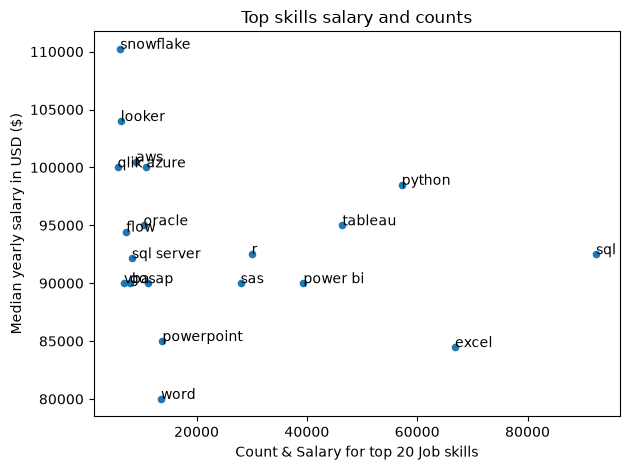

In [18]:
skill_stats.plot(kind = 'scatter', x = 'skill_count', y = 'median_salary')
plt.title('Top skills salary and counts')
plt.xlabel(f'Count & Salary for top {skill_count} Job skills')
plt.ylabel('Median yearly salary in USD ($)')
plt.tight_layout()

for i, txt in enumerate(skill_stats.index):
    plt.text(skill_stats['skill_count'].iloc[i], skill_stats['median_salary'].iloc[i], txt)

In [14]:
%pip install adjustText

Note: you may need to restart the kernel to use updated packages.


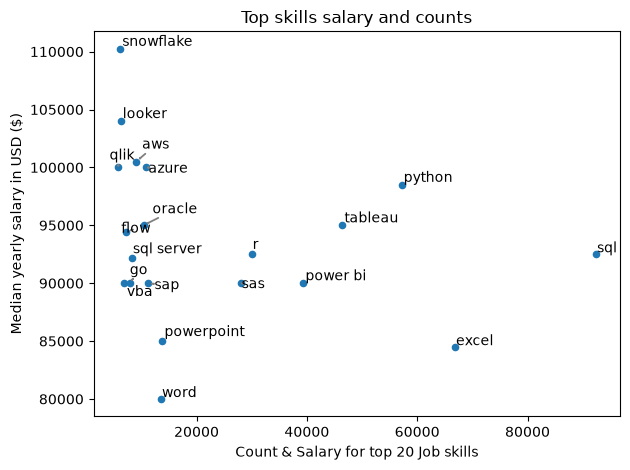

In [23]:
from adjustText import adjust_text

skill_stats.plot(kind = 'scatter', x = 'skill_count', y = 'median_salary')
plt.title('Top skills salary and counts')
plt.xlabel(f'Count & Salary for top {skill_count} Job skills')
plt.ylabel('Median yearly salary in USD ($)')
plt.tight_layout()

texts = []
for i, txt in enumerate(skill_stats.index):
    texts.append(plt.text(skill_stats['skill_count'].iloc[i], skill_stats['median_salary'].iloc[i], txt))

adjust_text(texts, arrowprops = dict(arrowstyle = '->', color = 'gray', lw= 1.3))
plt.show()



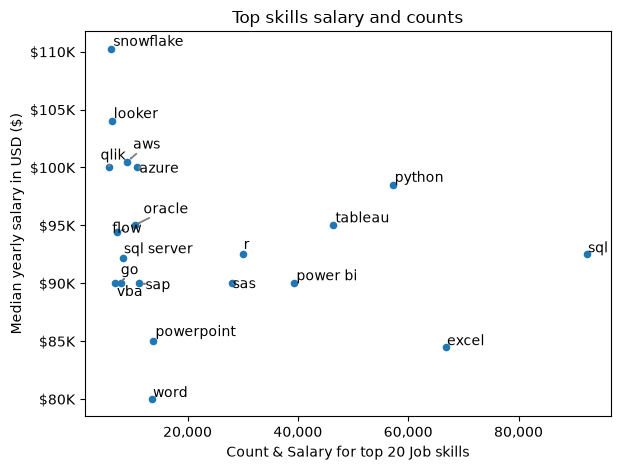

In [27]:
skill_stats.plot(kind = 'scatter', x = 'skill_count', y = 'median_salary')
plt.title('Top skills salary and counts')
plt.xlabel(f'Count & Salary for top {skill_count} Job skills')
plt.ylabel('Median yearly salary in USD ($)')
plt.tight_layout()

ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos: f'${int(y/1000)}K'))
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'{int(x):,}'))


texts = []
for i, txt in enumerate(skill_stats.index):
    texts.append(plt.text(skill_stats['skill_count'].iloc[i], skill_stats['median_salary'].iloc[i], txt))

adjust_text(texts, arrowprops = dict(arrowstyle = '->', color = 'gray', lw= 1.3))
plt.show()



In [1]:
####################################################################################

In [ ]:
###   HISTOGRAMS   ###

In [5]:
df_us_da = df[(df['job_title_short'] == 'Data Analyst') & (df['job_country'] == 'United States')].copy()
df_us_da

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills
36,Data Analyst,Data Analyst,"Des Moines, IA",via Trabajo.org,Full-time,False,"Illinois, United States",2023-11-06 13:01:22,False,True,United States,NaN,NaN,NaN,Assuredpartners,NaN,NaN
68,Data Analyst,Sr. Research Data Analyst,"Baltimore, MD",via ZipRecruiter,Full-time,False,"New York, United States",2023-03-24 13:01:00,False,False,United States,NaN,NaN,NaN,Johns Hopkins Medicine,"[r, zoom]","{'programming': ['r'], 'sync': ['zoom']}"
73,Data Analyst,Entry level / Systems Data Analyst (Remote),Anywhere,via LinkedIn,Contractor,True,"Illinois, United States",2023-06-16 13:18:22,True,True,United States,NaN,NaN,NaN,Soft Magic,"[word, excel, powerpoint, outlook]","{'analyst_tools': ['word', 'excel', 'powerpoin..."
79,Data Analyst,Data Analyst/Report Writer,"Austin, TX",via Jobs Trabajo.org,Full-time,False,"Texas, United States",2023-08-07 13:18:27,True,False,United States,NaN,NaN,NaN,Nesco Resource,"[sas, sas, word, excel]","{'analyst_tools': ['sas', 'word', 'excel'], 'p..."
93,Data Analyst,IT Finance / TBM Data Analyst - Remote | WFH,Anywhere,via LinkedIn,Full-time,True,"New York, United States",2023-06-10 13:00:05,False,False,United States,NaN,NaN,NaN,Get It Recruit - Information Technology,"[oracle, azure, power bi, excel, word, powerpo...","{'analyst_tools': ['power bi', 'excel', 'word'..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
785603,Data Analyst,Junior Data Analyst,"Santa Monica, CA",via Trabajo.org,Full-time,False,"California, United States",2023-09-12 06:00:50,False,False,United States,NaN,NaN,NaN,"Ramax Search, Inc.","[sql, vba, python, excel, flow]","{'analyst_tools': ['excel'], 'other': ['flow']..."
785626,Data Analyst,Data Acquisition Associate,"Tarrytown, NY",via Trabajo.org,Full-time,False,"New York, United States",2023-10-29 06:01:29,False,False,United States,NaN,NaN,NaN,Planet Group,[microsoft teams],{'sync': ['microsoft teams']}
785685,Data Analyst,Data Analyst,"Indianapolis, IN",via Trabajo.org,Full-time,False,"Illinois, United States",2023-07-16 06:01:27,True,False,United States,NaN,NaN,NaN,"Aara Technologies, Inc","[sql, excel]","{'analyst_tools': ['excel'], 'programming': ['..."
785703,Data Analyst,Data Analyst - CRYPTOGRAPHY - Full-time,Anywhere,via Snagajob,Full-time,True,"Texas, United States",2023-01-28 06:02:55,True,False,United States,NaN,NaN,NaN,Axelon Services Corporation,NaN,NaN


In [ ]:
df_us_da['salary_year_avg']

salary_year_avg
90000.0     276
115000.0    179
70000.0     138
65000.0     129
100000.0    129
           ... 
121025.0      1
202000.0      1
99223.5       1
118050.0      1
198000.0      1
Name: count, Length: 1024, dtype: int64

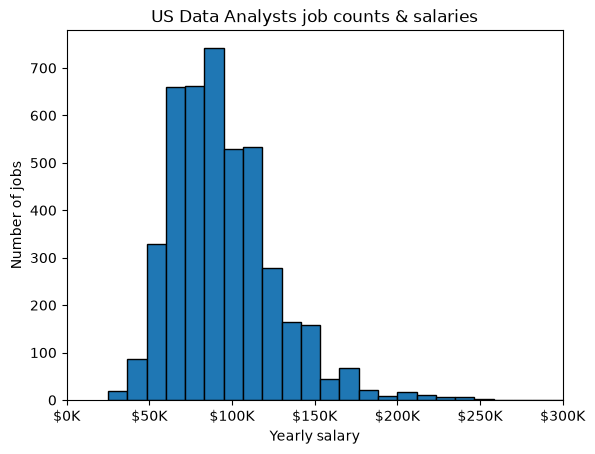

In [13]:
df_us_da['salary_year_avg'].plot(kind = 'hist', bins = 30, edgecolor = 'black')
plt.xlim(0, 300000)
plt.title('US Data Analysts job counts & salaries')
plt.xlabel('Yearly salary')
plt.ylabel('Number of jobs')

ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'${int(x/1000)}K'))

In [14]:
###############################################################################

In [15]:
###   BOX PLOTS   ###

In [17]:
df_us_da = df_us_da.dropna(subset = 'salary_year_avg')

In [18]:
df_us_da['salary_year_avg'].sample(10)

300532     72500.000000
76429      90490.000000
274253    125000.000000
728041     87500.000000
586825     89315.203125
32824      97500.000000
84032     135000.000000
685969    115000.000000
264846     68825.000000
9455       99150.000000
Name: salary_year_avg, dtype: float64

<Axes: >

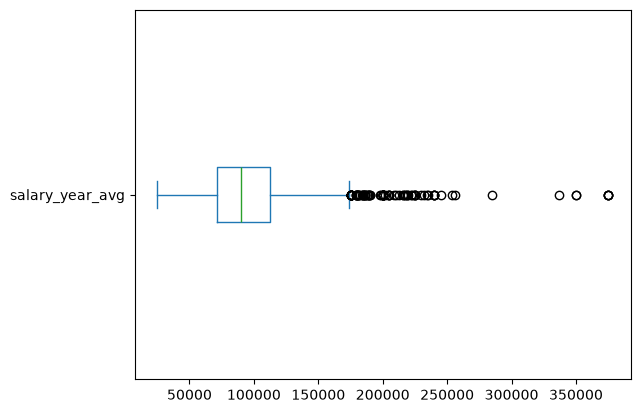

In [24]:
df_us_da['salary_year_avg'].plot(kind = 'box', vert = False)

# pandas plotting

C:\Users\user\AppData\Local\Temp\ipykernel_17932\4231489265.py:2: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df_us_da['salary_year_avg'], vert = False)


{'whiskers': [<matplotlib.lines.Line2D at 0x23b547150d0>,
 'caps': [<matplotlib.lines.Line2D at 0x23b5470d760>,
 'boxes': [<matplotlib.lines.Line2D at 0x23b54714e30>],
 'medians': [<matplotlib.lines.Line2D at 0x23b54715a30>],
 'fliers': [<matplotlib.lines.Line2D at 0x23b54715cd0>],
 'means': []}

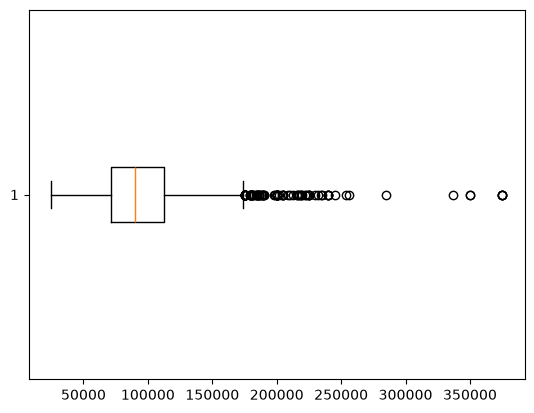

In [26]:
# MATPLOTLIB plotting
plt.boxplot(df_us_da['salary_year_avg'], vert = False)

In [27]:
###########################################################################

In [54]:
job_titles = ['Data Analyst', 'Data Engineer', 'Data Scientist']

df_us = df[(df['job_title_short'].isin(job_titles)) & (df['job_country'] == 'United States')].copy()

df_us = df_us.dropna(subset= ['salary_year_avg'])

In [55]:
job_list = [df_us[df_us['job_title_short'] == job_title]['salary_year_avg'] for job_title in job_titles]
job_list

[109        89000.0
 180        90250.0
 410       133285.0
 988        62623.0
 1413       71300.0
             ...   
 782637     70000.0
 782798    111175.0
 783588    125000.0
 783866    115000.0
 784882     87500.0
 Name: salary_year_avg, Length: 4350, dtype: float64,
 92        120000.0
 146       129500.0
 307       185000.0
 339       195000.0
 380        97500.0
             ...   
 783111    125000.0
 784102     90000.0
 784191    217500.0
 785624    139216.0
 785641    150000.0
 Name: salary_year_avg, Length: 2915, dtype: float64,
 100       228222.0
 116       114000.0
 257       103128.0
 450       157500.0
 1257       70700.0
             ...   
 785324    234500.0
 785488    115000.0
 785563    136400.0
 785648    221875.0
 785692    157500.0
 Name: salary_year_avg, Length: 4553, dtype: float64]

C:\Users\user\AppData\Local\Temp\ipykernel_17932\4029603515.py:1: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(job_list, tick_labels = job_titles, vert = False)


{'whiskers': [<matplotlib.lines.Line2D at 0x23b5521b7d0>,
 'caps': [<matplotlib.lines.Line2D at 0x23b5521a9c0>,
 'boxes': [<matplotlib.lines.Line2D at 0x23b548cc110>,
 'medians': [<matplotlib.lines.Line2D at 0x23b5521a540>,
 'fliers': [<matplotlib.lines.Line2D at 0x23b5521a660>,
 'means': []}

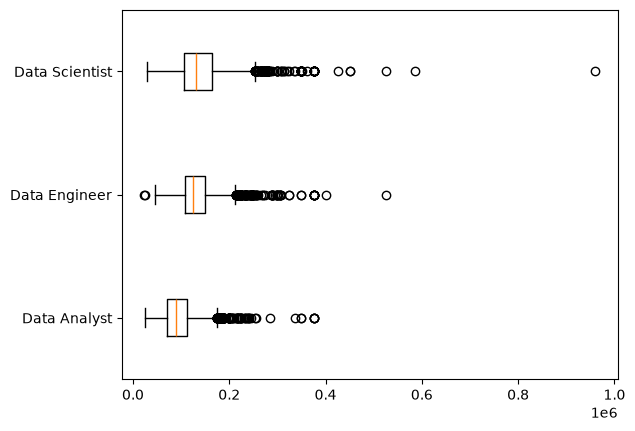

In [57]:
plt.boxplot(job_list, tick_labels = job_titles, vert = False)

C:\Users\user\AppData\Local\Temp\ipykernel_17932\3064906283.py:1: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(job_list, tick_labels = job_titles, vert = False)


(0.0, 700000.0)

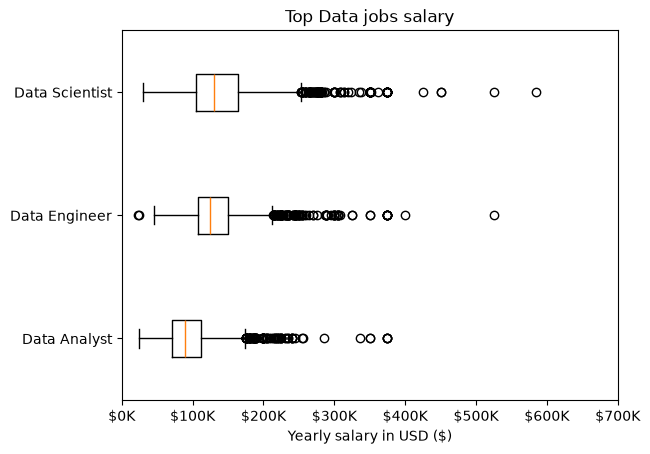

In [61]:
plt.boxplot(job_list, tick_labels = job_titles, vert = False)
plt.title('Top Data jobs salary')
plt.xlabel('Yearly salary in USD ($)')

ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'${int(x/1000)}K'))
plt.xlim(0, 700000)

In [62]:
##########################################################################################

In [ ]:
df_us_da

In [64]:
df_us_da = df_us_da.explode('job_skills')

In [66]:
df_us_da_grouped = df_us_da.groupby('job_skills')['salary_year_avg'].agg(['count', 'median'])
# agg func respectively: 'count' for job_skills; 'median' for salary

In [69]:
df_us_da_toppay = df_us_da_grouped.sort_values('median', ascending = False).head(10)
df_us_da_toppay

,count,median
job_skills,,
dplyr,2,196250.0
bitbucket,3,189000.0
gitlab,3,186000.0
solidity,1,179000.0
hugging face,1,175000.0
couchbase,1,160515.0
ansible,1,159640.0
mxnet,2,149000.0
cassandra,6,148250.0


In [74]:
df_us_da_skills = df_us_da_grouped.sort_values('count', ascending = False).head(10).sort_values('median', ascending = False)
df_us_da_skills

,count,median
job_skills,,
python,1431,97500.00
tableau,1364,92875.00
r,893,92500.00
sql server,286,92500.00
sql,2508,91000.00
sas,926,90000.00
power bi,838,90000.00
powerpoint,462,85000.00
excel,1808,84392.00


<Axes: ylabel='job_skills'>

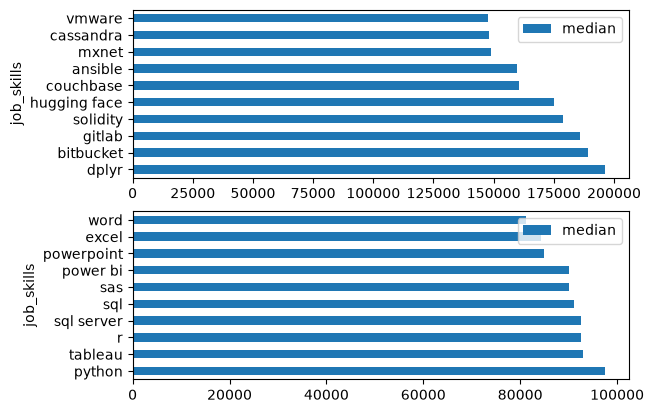

In [75]:
fig, ax = plt.subplots (2, 1)

df_us_da_toppay.plot(kind = 'barh', ax= ax[0], y = 'median')
df_us_da_skills.plot(kind = 'barh', ax = ax[1], y = 'median')

(0.0, 200000.0)

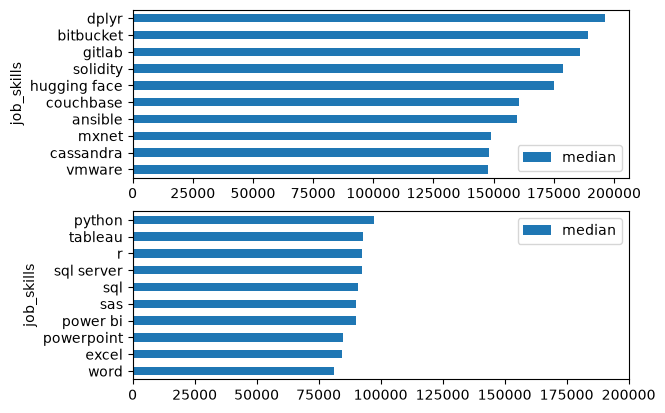

In [84]:
fig, ax = plt.subplots (2, 1)

df_us_da_toppay[::-1].plot(kind = 'barh', ax= ax[0], y = 'median')
df_us_da_skills[::-1].plot(kind = 'barh', ax = ax[1], y = 'median')
ax[1].set_xlim(0, 200000)
# [::-1]  as steps  = reverse

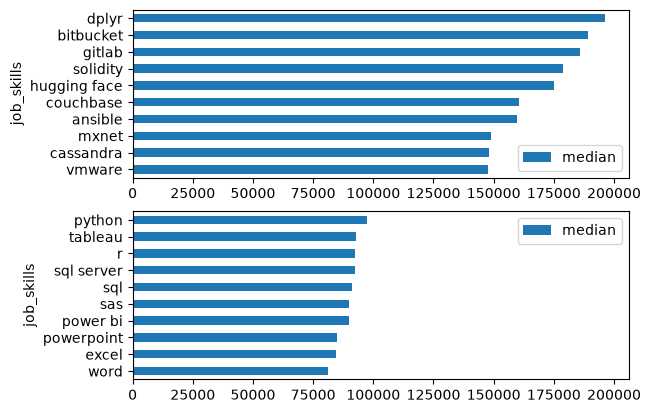

In [85]:
fig, ax = plt.subplots (2, 1)

df_us_da_toppay.plot(kind = 'barh', ax= ax[0], y = 'median')
ax[0].invert_yaxis()
df_us_da_skills.plot(kind = 'barh', ax = ax[1], y = 'median')
ax[1].set_xlim(ax[0].get_xlim())
ax[1].invert_yaxis()

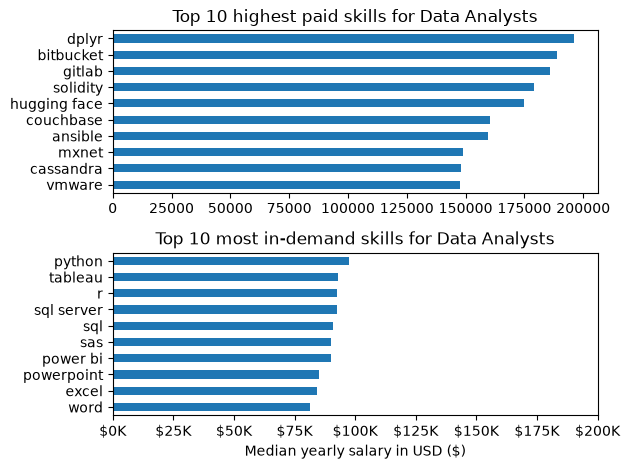

In [91]:
fig, ax = plt.subplots (2, 1)

df_us_da_toppay[::-1].plot(kind = 'barh', ax= ax[0], y = 'median', legend = False)
ax[0].set_title('Top 10 highest paid skills for Data Analysts')
ax[0].set_xlabel('')
ax[0].set_ylabel('')
ax[0] = plt.gca()
ax[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'${int(x/1000)}K'))

df_us_da_skills[::-1].plot(kind = 'barh', ax = ax[1], y = 'median', legend = False)
ax[1].set_xlim(0, 200000)
ax[1].set_title('Top 10 most in-demand skills for Data Analysts')
ax[1].set_xlabel('Median yearly salary in USD ($)')
ax[1].set_ylabel('')
ax[1] = plt.gca()
ax[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'${int(x/1000)}K'))

fig.tight_layout()

In [90]:
import seaborn as sns

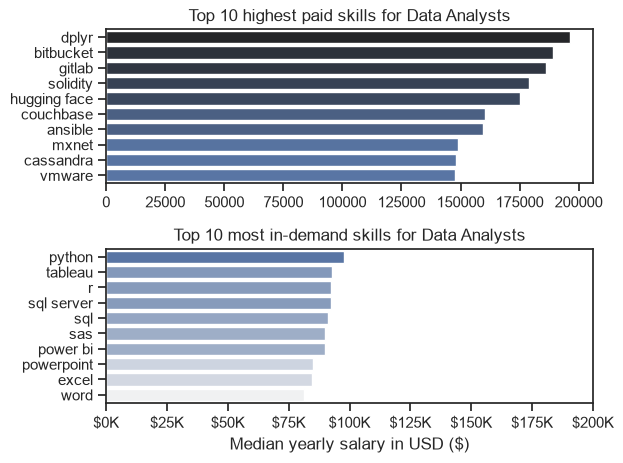

In [100]:
fig, ax = plt.subplots (2, 1)

sns.set_theme(style = 'ticks')
# df_us_da_toppay[::-1].plot(kind = 'barh', ax= ax[0], y = 'median', legend = False)
sns.barplot(data = df_us_da_toppay, x = 'median', y = df_us_da_toppay.index, ax= ax[0], hue = 'median', palette = 'dark:b_r')
ax[0].legend().remove()
ax[0].set_title('Top 10 highest paid skills for Data Analysts')
ax[0].set_xlabel('')
ax[0].set_ylabel('')
ax[0] = plt.gca()
ax[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'${int(x/1000)}K'))

# df_us_da_skills[::-1].plot(kind = 'barh', ax = ax[1], y = 'median', legend = False)
sns.barplot(data = df_us_da_skills, x = 'median', y = df_us_da_skills.index, ax= ax[1], hue = 'median', palette = 'light:b')
ax[1].legend().remove()
ax[1].set_xlim(0, 200000)
ax[1].set_title('Top 10 most in-demand skills for Data Analysts')
ax[1].set_xlabel('Median yearly salary in USD ($)')
ax[1].set_ylabel('')
ax[1] = plt.gca()
ax[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'${int(x/1000)}K'))

fig.tight_layout()

In [101]:
##########################################################################################

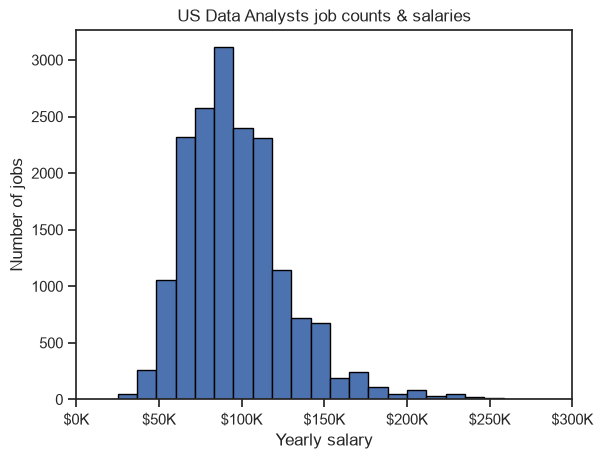

In [102]:
df_us_da['salary_year_avg'].plot(kind = 'hist', bins = 30, edgecolor = 'black')

plt.xlim(0, 300000)
plt.title('US Data Analysts job counts & salaries')
plt.xlabel('Yearly salary')
plt.ylabel('Number of jobs')

ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'${int(x/1000)}K'))

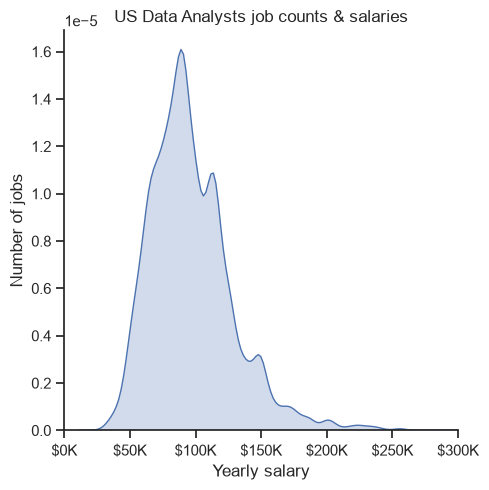

In [ ]:
sns.displot(df_us_da['salary_year_avg'], kind = 'kde', fill = True)

sns.set_theme(style='ticks')
plt.xlim(0, 300000)
plt.title('US Data Analysts job counts & salaries')
plt.xlabel('Yearly salary')
plt.ylabel('Number of jobs')

ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'${int(x/1000)}K'))


In [106]:
###############################################################

C:\Users\user\AppData\Local\Temp\ipykernel_17932\3064906283.py:1: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(job_list, tick_labels = job_titles, vert = False)


(0.0, 700000.0)

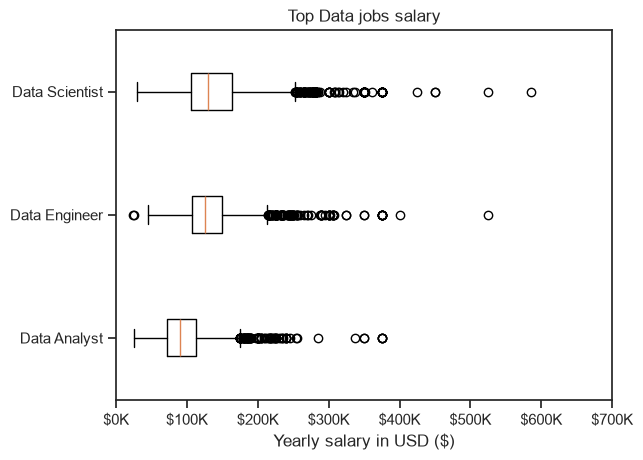

In [107]:
plt.boxplot(job_list, tick_labels = job_titles, vert = False)
plt.title('Top Data jobs salary')
plt.xlabel('Yearly salary in USD ($)')

ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'${int(x/1000)}K'))
plt.xlim(0, 700000)

Text(0, 0.5, ' ')

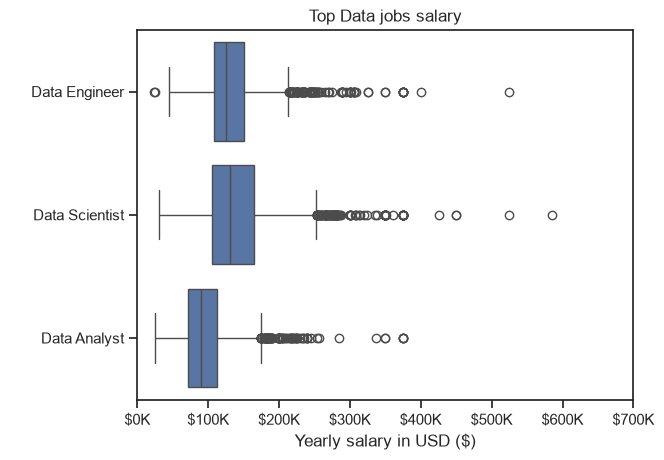

In [110]:
sns.boxplot(data = df_us, x = 'salary_year_avg', y = 'job_title_short')

plt.title('Top Data jobs salary')
plt.xlabel('Yearly salary in USD ($)')

ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'${int(x/1000)}K'))
plt.xlim(0, 700000)

plt.ylabel(" ")